# STAT 207 Project 01 - How Hours Played Affects Sleep Quality

Asher Chan

Sam Bihari

## Contribution Report

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

grade this submission

If you said **my submission is under netID** above, we will not grade any of your project submission.

If you said **grade this submission** above, who worked with you on this project?  Write both their **names** and **netIDs**.  

Sam sbihari2

You should list the contribution of each team member to the report.

*For example:*

*John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*

OR

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

1. Asher Chan (achan99) completed parts 1-3

2. Sam Bihari (sbihari2) completed parts 4-5

Group Work Reflection

Reflecting on your experience working as a group, how do you think the project went?  What were the most effective things your group did to work together?  What were the least effective things your group did to work together?  What have you learned about group work from this project?  What might you change about your group's process or dynamics for the next project?  Did you face any substantial challenges in working together?  If so, please explain any challenges that you had.

*Note*: this can be completed individually or as a group, and each person can submit their own reflection to their own repository/submission or completely within the group submission.  If you would like your TA to read your individual reflection and yours is not the submission to be graded, be sure to email your TA.

This project went pretty well and we were able to split up the work well between the two of us. Communication worked well and we were both able to take away some valuable lessons from this project.

## Introduction

Personal Motivation

We chose this dataset as we have both found that videogames have played a crucial part of both of our childhoods being surrounded by it all of our lives. Through this common ground we decided that it would be interesting and informative for the both of us and readers a like, to see how certain video games and certain hours played can affect the overall sleep quality and sleep hours that an individual will get.

Research Question

 Does the number of hours spent playing video games affect the sleep quality of an individual?

 Contextual Importance

 Understanding the relation between hours played and the overall sleep quality of a person is something that we think all active or non-active gamers can benefit from. Often times people can find themselves mindlessly getting sucked into playing a video game for hours and hours on end with no sign of stopping. This unchecked play time usually leads to poor sleep schedules and poor routines. By verifying our research question we are able to push forth an understanding of the negative effects of prolonged time spent playing video games. By understanding this relationship individuals can become more aware of how much time they're spending on playing video games and when they should be getting off the game before going to bed.

In [1]:
#Imports here
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
from scipy.stats import bernoulli
from scipy.stats import binom

In [2]:
df = pd.read_csv('Gaming and Mental Health.csv')
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

## 2. Dataset Discussion

This dataset was found through Kaggle when browsing for datasets related to video games and mental health behavior. LINK: https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health ! The original kaggle post does not indicate the original way that the data was collected but it can be infered by the description that the dataset was original created through a survey given key words used. The unit of observation for this dataset would be the daily gaming hours an individual spends. The two variables that we would like to focus on would be the daily gaming hours and the sleep quality of an individual. 

Some limitations that we can identify is the fact that we are not given the length of breaks given between gaming sessions or if there were any breaks in general. In addition we are unable to rule out the potential confounder of pre-determined health issues.

Observation: The dataframe below labled "addicted" displays the 10 users with the most daily hours spent playing video games. Through this specific dataframe we are able to view the relations between overall mental health and physical health in relation to the amount of hours spent playing games. Additionally there are further observations that can be made from this small dataframe further supporting the negative association of play time with overall well being.

In [10]:
addicted = df.nlargest(6, 'daily_gaming_hours')
addicted

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
69,GD0070,18,Female,15.1,MMO,World of Warcraft,PC,4.8,Fair,Often,...,False,True,True,0.0,4.2,10,0.0,209.75,6,High
258,GD0259,15,Male,15.1,Strategy,Age of Empires,Multi-platform,5.7,Fair,Sometimes,...,False,True,True,1.5,0.7,9,0.0,435.38,2,Moderate
865,GD0866,19,Male,14.7,Mobile Games,Genshin Impact,Multi-platform,3.5,Poor,Never,...,False,True,True,2.1,1.3,10,0.0,178.29,1,High
895,GD0896,30,Male,14.7,FPS,Call of Duty,Console,4.2,Poor,Sometimes,...,True,False,True,5.0,2.4,10,0.0,380.97,19,Severe
257,GD0258,27,Male,14.2,Strategy,StarCraft II,Multi-platform,3.4,Very Poor,Rarely,...,False,True,True,4.4,2.9,9,0.0,73.80,10,Moderate
491,GD0492,24,Male,14.1,Battle Royale,Fortnite,Multi-platform,3.9,Insomnia,Often,...,True,True,True,2.2,4.8,10,0.0,394.74,14,Severe


In [11]:
addicted.shape

(6, 27)

<Axes: xlabel='sleep_quality', ylabel='daily_gaming_hours'>

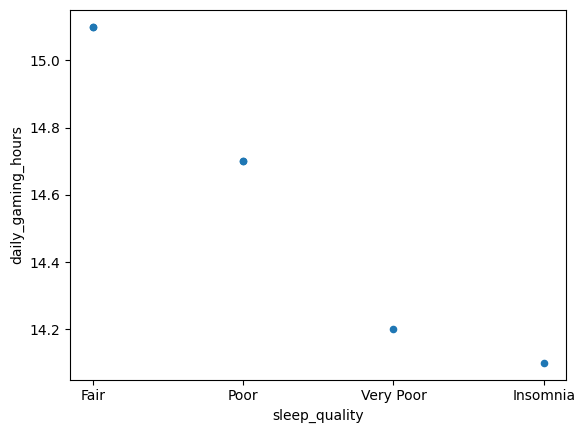

In [17]:
addicted.plot.scatter(y='daily_gaming_hours', x='sleep_quality')

## 3. Dataset Cleaning

In [5]:
df.value_counts()

record_id  age  gender  daily_gaming_hours  game_genre     primary_game       gaming_platform  sleep_hours  sleep_quality  sleep_disruption_frequency  academic_work_performance  grades_gpa  work_productivity_score  mood_state  mood_swing_frequency  withdrawal_symptoms  loss_of_other_interests  continued_despite_problems  eye_strain  back_neck_pain  weight_change_kg  exercise_hours_weekly  social_isolation_score  face_to_face_social_hours_weekly  monthly_game_spending_usd  years_gaming  gaming_addiction_risk_level
GD0002     21   Male    3.0                 MOBA           Dota 2             PC               7.2          Fair           Rarely                      Good                       3.75        2.0                      Irritable   Often                 False                False                    False                       False       False           0.4               8.5                    2                       10.7                              46.64                      1   

In [21]:
def check_missing_values(df):
    # define what counts as a "missing" value in string form
    missing_formats = ["nan", "none", "null", "na", "n/a", "missing", "unknown", "undefined", "-", ""]
    
    found_any = False

    for col in df.columns:
        col_missing = {}

        # count actual NaN/None values
        nan_count = df[col].isnull().sum()
        if nan_count > 0:
            col_missing["NaN/None"] = nan_count

        # count string-based missing values
        if df[col].dtype == "object":
            for fmt in missing_formats:
                count = df[col].str.strip().str.lower().eq(fmt).sum()
                if count > 0:
                    col_missing[f'"{df[col][df[col].str.strip().str.lower() == fmt].iloc[0]}"'] = count

        if col_missing:
            found_any = True
            total = sum(col_missing.values())
            pct = (total / len(df)) * 100
            print(f"\n  {col} — {total} missing ({pct:.2f}%):")
            for fmt, count in col_missing.items():
                print(f"    → {count} as {fmt}")

    if not found_any:
        print("No missing values found!")

#Claude helped formulate automation based on Asher's prompting

In [7]:
check_missing_values(df)


  grades_gpa — 246 missing (24.60%):
    → 246 as NaN/None

  work_productivity_score — 326 missing (32.60%):
    → 326 as NaN/None


In [8]:
dropped = pd.read_csv('Gaming and Mental Health.csv', na_values=['NaN'])
dropped = dropped.dropna()
dropped

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
5,GD0006,21,Male,2.1,Mobile Games,Clash of Clans,PC,7.5,Fair,Rarely,...,False,False,False,0.2,10.8,1,9.6,8.63,4,Low
6,GD0007,21,Male,2.7,FPS,Call of Duty,Multi-platform,7.2,Very Poor,Often,...,False,False,False,0.8,10.0,2,10.1,35.25,3,Low
13,GD0014,22,Male,5.1,RPG,Skyrim,Mobile,5.3,Fair,Never,...,False,True,False,0.9,7.6,3,6.3,36.07,5,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,GD0982,22,Female,13.6,Strategy,Civilization VI,Multi-platform,5.8,Poor,Rarely,...,False,True,False,1.4,2.4,8,0.0,438.83,2,Severe
987,GD0988,19,Male,4.7,MOBA,Dota 2,Console,6.7,Fair,Often,...,False,False,False,2.9,6.5,2,9.0,59.91,9,Low
988,GD0989,20,Male,4.4,MMO,Final Fantasy XIV,PC,5.4,Very Poor,Sometimes,...,False,False,False,1.0,9.7,3,12.1,8.08,7,Low
990,GD0991,19,Female,7.0,FPS,Valorant,PC,3.2,Fair,Often,...,False,False,True,1.4,7.7,5,5.8,121.06,2,Moderate


## 4. Summarizing Data

The research question that we chose was " Does the number of hours spent playing video games affect the sleep quality of an individual?"

<Axes: xlabel='sleep_quality', ylabel='daily_gaming_hours'>

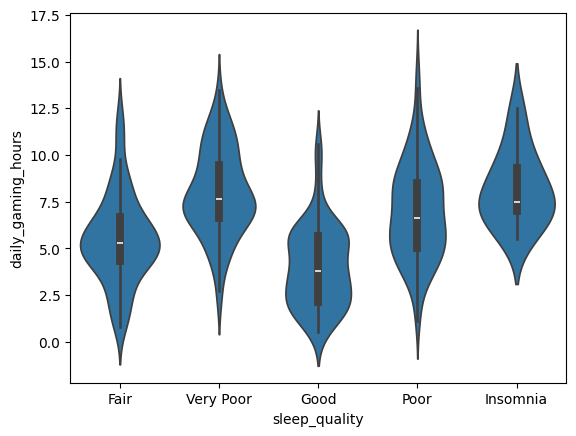

In [19]:
sns.violinplot(y='daily_gaming_hours', x='sleep_quality', data=dropped)

In [20]:
df[['daily_gaming_hours', 'sleep_quality']].groupby('sleep_quality').describe()

daily_gaming_hours                                               \
                           count      mean       std  min    25%  50%     75%   
sleep_quality                                                                   
Fair                       293.0  5.433447  2.538048  0.5  4.000  5.2   6.400   
Good                       212.0  4.049057  2.290253  0.5  2.275  3.7   5.625   
Insomnia                    37.0  8.651351  2.324581  5.5  7.000  7.6   9.700   
Poor                       283.0  6.937456  2.523523  0.7  4.950  6.8   8.600   
Very Poor                  175.0  8.100571  2.486157  0.6  6.600  7.8  10.000   

                     
                max  
sleep_quality        
Fair           15.1  
Good           12.2  
Insomnia       14.1  
Poor           14.7  
Very Poor      14.2

Part D:

The visualization and numerical summaries show a clear relationship between sleep quality and daily gaming hours. Overall, individuals reporting worse sleep quality tend to spend more time gaming per day. Looking at the centers of the distributions, the median and mean gaming hours are highest for the insomnia group (median = 7.6 hours, mean = 8.65 hours) and Very Poor sleep group (median = 7.8, mean = 8.10 hours). The poor sleep group has a slightly lower median (6.8 hours), followed by the Fair Group (median = 5.2 hours). The Good sleep group has the lowest gaming time (median = 3.7 hours, mean = 4.04 hours). This suggests a negative association between sleep quality and gaming time. In terms of spread, all groups exhibit moderate variability, with standard deviations ranging from 2.2 to 2.5 hours. The violin plot indicates fairly wide distributions for most categories, especially Insomnia, Very Poor, and Poor, which have longer upper tails reaching about 12-15 hours. This suggests some heavy gamers in those groups, which are pulling the mean higher than the median. The Good sleep group is more concentrated at lower gaming hours, with most values between about 2 and 6 hours. The shapes of the distributions appear slightly right-skewed for several poorer sleep categories, indicating a few individuals with very high gaming times. There is also noticeable overlap between adjacent sleep categories, meaning gaming time alone does not perfectly separate sleep quality groups.

Part E:

These results provide evidence that supports the research question examining the relationship between sleep quality and daily gaming hours. Both the visualization and numerical summaries show a consistent pattern: as sleep quality worsens, average gaming time tends to increase. Individuals reporting insomnia and very poor sleep have the highest mean and median gaming hours, while those with good sleep report the lowest. Although there is some overlap between groups, the overall trend suggests a negative association between sleep quality and gaming time. Because these findings are based on a sample of individuals rather than the entire population, the results should be interpreted as siggestive of a broader pattern rather than for sure causation. This indicates that higher amounts of daily gaming may be related to poorer sleep outcomes, though the results show association rather than causation.

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

## 5. Conclusion

##### Conclusion

In this analysis, we explored the relationship between sleep quality and daily gaming hours using the provided dataset. After cleaning the data and organizing the sleep quality categories, we used numerical summaries and a violin plot to compare gaming behavior across different sleep qualities. The results showed a general pattern where individuals reporting worse sleep quality tended to have higher average gaming hours, which helps address the original research question about whether gaming time differs by sleep quality. There are several limitations to keep in mind when interpreting these results. First, the analysis is based on a sample rather than the full population, so the findings may not fully generalize to all individuals. Additionally , the data are observational, which means we cannot conclude that gaming causes poor sleep, only that the two appear to be associated in this sample. There may also be other factors (such as age, stress, or work schedules) that influence both gaming time and sleep quality but were not accounted for in this analysis.

For future work, it would be useful to incorporate additional variables that may affect sleep, such as screen time before bed. Running a formal statistical test could also help determine whether the differences between sleep quality groups are statistically significant. A longitudinal study following individuals over time would be especially valuable for better understanding the direction of the relationship between gaming and sleep.

## AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class.  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

Yes

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

I used claude

I asked the agent to develop a function that can iterate through all columns in the data set and identify any na values.

I typed out the code from claude and tweaked the variables based on the question in Part 3.